In [1]:
!pip install torch scikit-learn matplotlib seaborn pandas numpy

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report)

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.10.0+cu128
CUDA available: True


In [3]:
#load dataset ffrom sklearn
data = load_breast_cancer()
X, y = data.data, data.target

df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y

print("Shape:", df.shape)
print("\nClass distribution:")
print(df['target'].value_counts().rename({0: 'Malignant', 1: 'Benign'}))
print("\nFirst 5 rows:")
df.head()

Shape: (569, 31)

Class distribution:
target
Benign       357
Malignant    212
Name: count, dtype: int64

First 5 rows:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [4]:
#split before scaling to avoid data_leak
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

#scaler on train only
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

#convert to pytorch tensors
def to_tensor(X, y):
    return (torch.tensor(X, dtype=torch.float32),
            torch.tensor(y, dtype=torch.long))

X_tr, y_tr = to_tensor(X_train, y_train)
X_v,  y_v  = to_tensor(X_val,   y_val)
X_te, y_te = to_tensor(X_test,  y_test)

Train: (398, 30), Val: (85, 30), Test: (86, 30)


In [5]:
train_ds = TensorDataset(X_tr, y_tr)
val_ds   = TensorDataset(X_v,  y_v)
test_ds  = TensorDataset(X_te, y_te)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=32)
test_loader  = DataLoader(test_ds,  batch_size=32)

print(f"Batches per epoch: {len(train_loader)}")
for xb, yb in train_loader:
    print(f"Batch shape: {xb.shape}, Labels: {yb.shape}")
    break

Batches per epoch: 13
Batch shape: torch.Size([32, 30]), Labels: torch.Size([32])


In [6]:
#V1 nn.Sequential
model_seq = nn.Sequential(
    nn.Linear(30, 64),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(32, 2)
)

print(model_seq)
total_params = sum(p.numel() for p in model_seq.parameters())
print(f"\nTotal parameters: {total_params:,}")

Sequential(
  (0): Linear(in_features=30, out_features=64, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.3, inplace=False)
  (3): Linear(in_features=64, out_features=32, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.3, inplace=False)
  (6): Linear(in_features=32, out_features=2, bias=True)
)

Total parameters: 4,130


In [7]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, output_dim, dropout=0.3):
        super(MLP, self).__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, output_dim))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

model_custom = MLP(input_dim=30, hidden_dims=[64, 32], output_dim=2)
print(model_custom)
print(f"\nTotal parameters: {sum(p.numel() for p in model_custom.parameters()):,}")

MLP(
  (network): Sequential(
    (0): Linear(in_features=30, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=2, bias=True)
  )
)

Total parameters: 4,130


In [8]:
print("Named_parameters()")
for name, param in model_custom.named_parameters():
    print(f"  {name:40s} shape: {list(param.shape)}")

print("\nState_dict() keys")
for key in model_custom.state_dict():
    print(f"  {key}")

print("\nSample weight tensor ")
first_layer_w = model_custom.state_dict()['network.0.weight']
print(f"  Shape: {first_layer_w.shape}")
print(f"  Mean:  {first_layer_w.mean():.4f}")
print(f"  Std:   {first_layer_w.std():.4f}")

Named_parameters()
  network.0.weight                         shape: [64, 30]
  network.0.bias                           shape: [64]
  network.3.weight                         shape: [32, 64]
  network.3.bias                           shape: [32]
  network.6.weight                         shape: [2, 32]
  network.6.bias                           shape: [2]

State_dict() keys
  network.0.weight
  network.0.bias
  network.3.weight
  network.3.bias
  network.6.weight
  network.6.bias

Sample weight tensor 
  Shape: torch.Size([64, 30])
  Mean:  0.0001
  Std:   0.1054


In [9]:
def init_weights(model, strategy='xavier'):
    for m in model.modules():
        if isinstance(m, nn.Linear):
            if strategy == 'gaussian':
                nn.init.normal_(m.weight, mean=0, std=0.01)
                nn.init.zeros_(m.bias)
            elif strategy == 'constant':
                nn.init.constant_(m.weight, 0.1)
                nn.init.constant_(m.bias, 0.0)
            elif strategy == 'xavier':
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

#test each strategy
for strategy in ['gaussian', 'constant', 'xavier']:
    m = MLP(30, [64, 32], 2)
    init_weights(m, strategy)
    w = m.state_dict()['network.0.weight']
    print(f"[{strategy:10s}] mean={w.mean():.4f}, std={w.std():.4f}")

[gaussian  ] mean=0.0002, std=0.0100
[constant  ] mean=0.1000, std=0.0000
[xavier    ] mean=0.0025, std=0.1432


In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = MLP(30, [64, 32], 2).to(device)
init_weights(model, 'xavier')

optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

best_val_acc = 0.0
train_losses, val_accs = [], []

for epoch in range(1, 51):
    #training
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    train_losses.append(total_loss / len(train_loader))

    #validation
    model.eval()
    correct = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb).argmax(dim=1)
            correct += (preds == yb).sum().item()
    val_acc = correct / len(y_val)
    val_accs.append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | Loss: {train_losses[-1]:.4f} | Val Acc: {val_acc:.4f}")

print(f"\nBest val accuracy: {best_val_acc:.4f}")

Using device: cuda
Epoch  10 | Loss: 0.0984 | Val Acc: 0.9765
Epoch  20 | Loss: 0.0527 | Val Acc: 0.9882
Epoch  30 | Loss: 0.0401 | Val Acc: 0.9765
Epoch  40 | Loss: 0.0341 | Val Acc: 0.9765
Epoch  50 | Loss: 0.0322 | Val Acc: 0.9765

Best val accuracy: 0.9882


In [11]:
#reload model from disk
model_loaded = MLP(30, [64, 32], 2).to(device)
model_loaded.load_state_dict(torch.load("best_model.pth", map_location=device))
model_loaded.eval()

print("Model loaded successfully!")

#compare predictions from original vs loaded model
model.eval()
with torch.no_grad():
    xb = X_te[:5].to(device)
    pred_orig   = model(xb).argmax(dim=1)
    pred_loaded = model_loaded(xb).argmax(dim=1)

print("Original predictions:", pred_orig.tolist())
print("Loaded   predictions:", pred_loaded.tolist())
print("Match:", torch.all(pred_orig == pred_loaded).item())

Model loaded successfully!
Original predictions: [1, 0, 0, 0, 1]
Loaded   predictions: [1, 0, 0, 0, 1]
Match: True


              precision    recall  f1-score   support

   Malignant       0.91      0.91      0.91        32
      Benign       0.94      0.94      0.94        54

    accuracy                           0.93        86
   macro avg       0.93      0.93      0.93        86
weighted avg       0.93      0.93      0.93        86



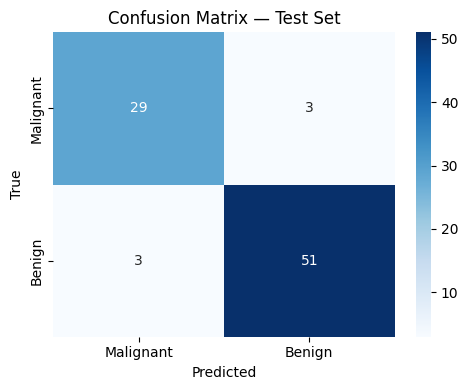

In [12]:
model_loaded.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        preds = model_loaded(xb).argmax(dim=1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(yb.tolist())

#metrics-
print(classification_report(all_labels, all_preds,
      target_names=['Malignant', 'Benign']))

#condusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Malignant','Benign'],
            yticklabels=['Malignant','Benign'])
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title("Confusion Matrix — Test Set")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

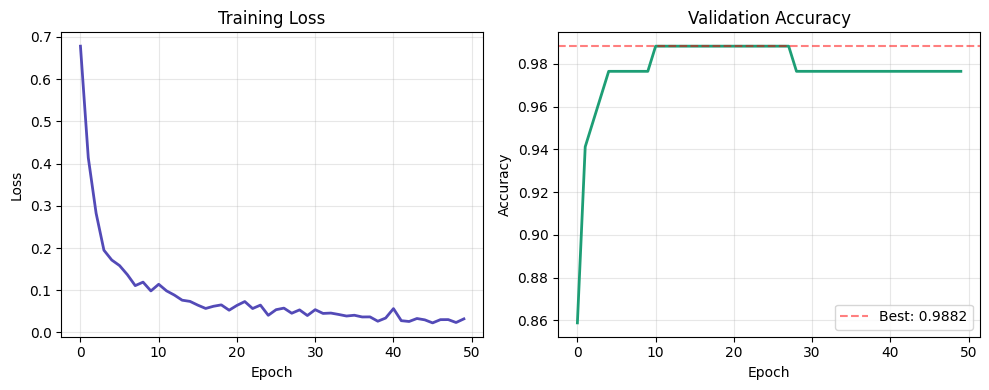

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.plot(train_losses, color='#534AB7', linewidth=2)
ax1.set_title("Training Loss")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.grid(alpha=0.3)

ax2.plot(val_accs, color='#1D9E75', linewidth=2)
ax2.set_title("Validation Accuracy")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
ax2.axhline(max(val_accs), color='red', linestyle='--',
            alpha=0.5, label=f'Best: {max(val_accs):.4f}')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()